# 02 — Cleaning + Enrichment Verification

**Week 2 verification runbook.**

Same pattern as notebook 01: each cell does one verifiable thing and asserts a result. By the end:

- Bedroom categorization populated as expected
- Top-50 areas have `display_name` covering ≥85% of volume
- Geocoded areas ≥95% of transaction volume
- IQR outlier flag rate is 4–15%
- Sample of 20 enriched rows looks correct

**Re-runnable**: every enrich subcommand is idempotent. To regenerate everything from scratch:
```bash
py -m src.db --migrate
py -m src.enrich --bedrooms
py -m src.enrich --names
py -m src.enrich --geocode
py -m src.enrich --outliers
py -m src.db --views
```

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

from src import config, db
print('db path:', config.DB_PATH.name)

db path: real_estate.db


## 1. Bedroom categorization coverage

In [2]:
with db.connect() as conn:
    bed = pd.read_sql(
        """SELECT COALESCE(bedroom_category, '(NULL)') AS bedroom_category,
                  COUNT(*) AS rows,
                  printf('%.1f%%', 100.0 * COUNT(*) / (SELECT COUNT(*) FROM transactions)) AS pct
           FROM transactions GROUP BY 1 ORDER BY rows DESC""",
        conn,
    )
bed

,bedroom_category,rows,pct
0,1BR,257262,24.8%
1,(NULL),246073,23.7%
2,2BR,185301,17.9%
3,Studio,133471,12.9%
4,3BR,107913,10.4%
5,Non-residential,67742,6.5%
6,4BR+,37981,3.7%
7,Penthouse,1779,0.2%


In [3]:
non_null_pct = bed[bed['bedroom_category'] != '(NULL)']['rows'].sum() / bed['rows'].sum()
print(f'Non-NULL bedroom_category rate: {non_null_pct:.1%}')
assert non_null_pct >= 0.70, f'Expected >=70% categorized, got {non_null_pct:.1%}'
print('PASS: bedroom_category populated for >=70% of rows')

Non-NULL bedroom_category rate: 76.3%
PASS: bedroom_category populated for >=70% of rows


## 2. Area display_name coverage

In [4]:
with db.connect() as conn:
    n_named = conn.execute(
        "SELECT COUNT(*) FROM areas WHERE display_name IS NOT NULL"
    ).fetchone()[0]
    total_txn = conn.execute('SELECT COUNT(*) FROM transactions').fetchone()[0]
    covered_txn = conn.execute(
        """SELECT COUNT(*) FROM transactions t JOIN areas a ON a.area_id = t.area_id
           WHERE a.display_name IS NOT NULL"""
    ).fetchone()[0]

print(f'Areas with display_name : {n_named}')
print(f'Txn coverage            : {covered_txn:,} / {total_txn:,}  ({100*covered_txn/total_txn:.1f}%)')
assert n_named >= 40, f'Expected >=40 named areas, got {n_named}'
assert covered_txn / total_txn >= 0.85, 'Expected >=85% txn coverage'
print('PASS: >=40 areas named, >=85% txn coverage')

Areas with display_name : 50
Txn coverage            : 939,565 / 1,037,522  (90.6%)
PASS: >=40 areas named, >=85% txn coverage


In [5]:
# Sample 10 mappings — what DLD canonical became what display name
with db.connect() as conn:
    sample = pd.read_sql(
        """SELECT a.area_name AS dld_canonical, a.display_name, COUNT(t.txn_id) AS txns
           FROM areas a LEFT JOIN transactions t ON t.area_id = a.area_id
           WHERE a.display_name IS NOT NULL GROUP BY a.area_id
           ORDER BY txns DESC LIMIT 10""",
        conn,
    )
sample

,dld_canonical,display_name,txns
0,Marsa Dubai,Dubai Marina,104330
1,Al Thanyah Fifth,Jumeirah Lakes Towers,75786
2,Business Bay,Business Bay,73592
3,Al Barsha South Fourth,Arjan,54116
4,Burj Khalifa,Downtown Dubai,54096
5,Al Warsan First,International City,49522
6,Jabal Ali First,Discovery Gardens & The Gardens,35124
7,Al Hebiah Fourth,DAMAC Hills,34885
8,Palm Jumeirah,Palm Jumeirah,34660
9,Al Thanyah Third,Barsha Heights (TECOM),28694


## 3. Geocoding coverage

In [6]:
with db.connect() as conn:
    geo_areas = conn.execute('SELECT COUNT(*) FROM areas WHERE lat IS NOT NULL').fetchone()[0]
    all_areas = conn.execute('SELECT COUNT(*) FROM areas').fetchone()[0]
    geo_txn = conn.execute(
        """SELECT COUNT(*) FROM transactions t JOIN areas a ON a.area_id = t.area_id
           WHERE a.lat IS NOT NULL"""
    ).fetchone()[0]
    named_geo = conn.execute(
        "SELECT COUNT(*) FROM areas WHERE display_name IS NOT NULL AND lat IS NOT NULL"
    ).fetchone()[0]
    named_total = conn.execute(
        "SELECT COUNT(*) FROM areas WHERE display_name IS NOT NULL"
    ).fetchone()[0]

print(f'Geocoded areas       : {geo_areas} / {all_areas}  ({100*geo_areas/all_areas:.1f}%)')
print(f'Geocoded txn volume  : {geo_txn:,} / {total_txn:,}  ({100*geo_txn/total_txn:.1f}%)')
print(f'Named areas geocoded : {named_geo} / {named_total}')
assert named_geo == named_total, 'All named areas should be geocoded (with overrides)'
print('PASS: all curated top-50 areas have lat/lon')

Geocoded areas       : 127 / 247  (51.4%)
Geocoded txn volume  : 981,938 / 1,037,522  (94.6%)
Named areas geocoded : 50 / 50
PASS: all curated top-50 areas have lat/lon


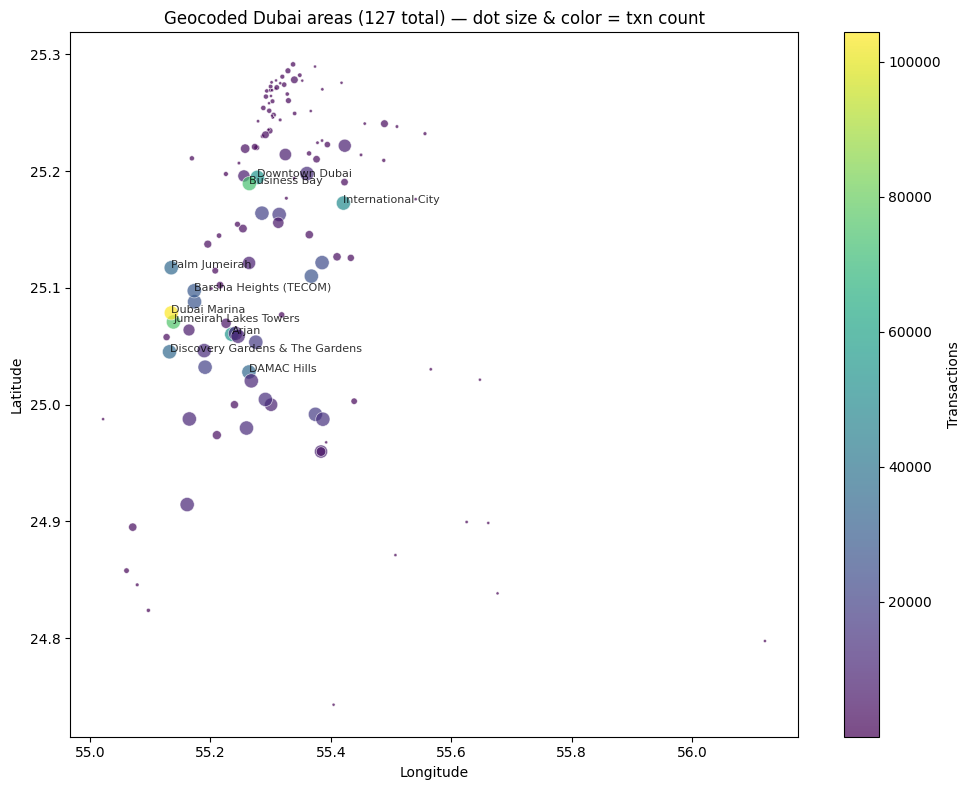

In [7]:
# Quick scatter of all geocoded areas — should form the shape of Dubai
with db.connect() as conn:
    geo = pd.read_sql(
        """SELECT a.area_id, COALESCE(a.display_name, a.area_name) AS name,
                  a.lat, a.lon, a.geocode_source, COUNT(t.txn_id) AS txns
           FROM areas a LEFT JOIN transactions t ON t.area_id = a.area_id
           WHERE a.lat IS NOT NULL GROUP BY a.area_id""",
        conn,
    )

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(geo['lon'], geo['lat'], s=geo['txns'].clip(upper=10000)/100 + 5,
                     c=geo['txns'], cmap='viridis', alpha=0.7,
                     edgecolors='white', linewidth=0.5)
for _, row in geo.nlargest(10, 'txns').iterrows():
    ax.annotate(row['name'], (row['lon'], row['lat']), fontsize=8, alpha=0.8)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Geocoded Dubai areas ({len(geo)} total) — dot size & color = txn count')
plt.colorbar(scatter, label='Transactions', ax=ax)
plt.tight_layout(); plt.show()

## 4. IQR outlier flag rate

In [8]:
with db.connect() as conn:
    iqr = pd.read_sql(
        """SELECT iqr_flag, COUNT(*) AS rows
           FROM transactions WHERE txn_type = 'Sales' AND price_per_sqft IS NOT NULL
           GROUP BY iqr_flag""",
        conn,
    )
total_sales = iqr['rows'].sum()
flag_rate = iqr[iqr['iqr_flag'] == 1]['rows'].sum() / total_sales
print(iqr)
print(f'\nFlag rate on Sales: {flag_rate:.2%}')
assert 0.04 <= flag_rate <= 0.20, f'Flag rate {flag_rate:.2%} outside 4-20% band'
print('PASS: outlier rate within expected band')

   iqr_flag    rows
0         0  744026
1         1   37221

Flag rate on Sales: 4.76%
PASS: outlier rate within expected band


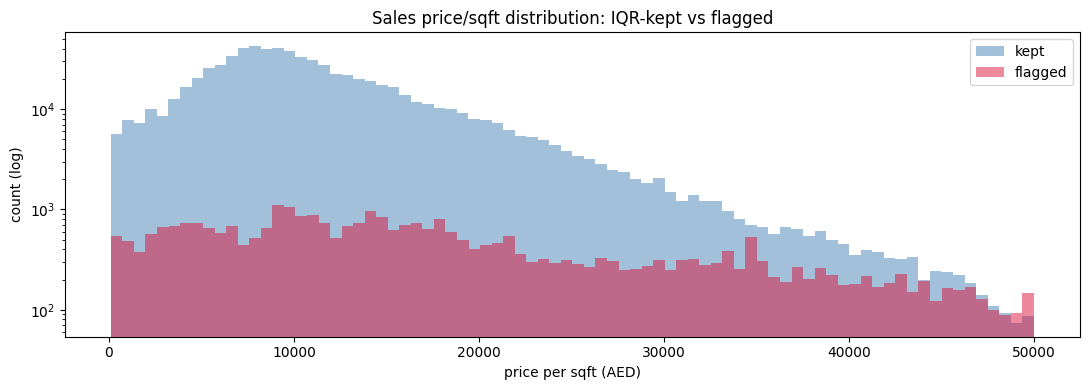

In [9]:
# Distribution of price_per_sqft — flagged vs unflagged
with db.connect() as conn:
    pps = pd.read_sql(
        """SELECT iqr_flag, price_per_sqft FROM transactions
           WHERE txn_type='Sales' AND price_per_sqft BETWEEN 100 AND 50000""",
        conn,
    )
fig, ax = plt.subplots(figsize=(11, 4))
for flag, col, lbl in [(0, 'steelblue', 'kept'), (1, 'crimson', 'flagged')]:
    pps.loc[pps['iqr_flag'] == flag, 'price_per_sqft'].plot.hist(
        bins=80, ax=ax, alpha=0.5, color=col, label=lbl, log=True)
ax.set_xlabel('price per sqft (AED)'); ax.set_ylabel('count (log)')
ax.set_title('Sales price/sqft distribution: IQR-kept vs flagged'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Spot-check 20 enriched rows (cleaned + categorized + flagged + with display_name)

In [10]:
with db.connect() as conn:
    spot = pd.read_sql(
        """SELECT t.txn_date,
                  COALESCE(a.display_name, a.area_name) AS area,
                  t.property_type, t.bedroom_category, t.is_offplan,
                  printf('%.0f', t.area_sqft)            AS sqft,
                  printf('%.0f', t.price_aed)            AS price_aed,
                  printf('%.0f', t.price_per_sqft)       AS pps,
                  t.iqr_flag
           FROM transactions t JOIN areas a ON a.area_id = t.area_id
           WHERE t.txn_type='Sales' AND t.txn_date BETWEEN '2022-01-01' AND '2022-12-31'
           ORDER BY RANDOM() LIMIT 20""",
        conn,
    )
spot

,txn_date,area,property_type,bedroom_category,is_offplan,sqft,price_aed,pps,iqr_flag
0,2022-12-29,Al Kifaf,Unit,3BR,0,191,3600000,18809,0
1,2022-09-28,Al Wasl (City Walk area),Unit,1BR,1,73,1720000,23636,0
2,2022-02-09,Meydan,Unit,Studio,1,31,536904,17494,0
3,2022-09-27,Umm Suqeim 3,Unit,1BR,1,75,1580000,21146,0
4,2022-09-16,Liwan,Unit,2BR,0,120,570000,4769,0
5,2022-08-17,Arjan,Unit,1BR,1,78,1096623,14094,0
6,2022-01-31,Mudon,Villa,3BR,0,186,1760000,9447,0
7,2022-12-29,Al Hebiah Second,Unit,Studio,1,36,456804,12868,0
8,2022-06-24,Business Bay,Unit,1BR,1,53,935704,17782,0
9,2022-10-17,Mirdif,Villa,2BR,0,185,1510142,8183,0


---
**Next:** [`03_enrichment.ipynb`](03_enrichment.ipynb) — first analytical pass on the cleaned data (monthly medians, YoY heatmap, off-plan vs ready gap, supply cycles).